# Treinamento DenseNet121 com PyTorch + GPU — v16 crop black borders

Notebook experimental baseado na configuração v12/check_v12, adicionando recorte automático de bordas escuras antes das transformações.


In [1]:
# CÉLULA 02 - Importações e verificação de GPU

import os
# Reduz fragmentação de memória CUDA em testes com imagens maiores.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import time
import random
from pathlib import Path
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
# CÉLULA 03 - Configurações gerais do experimento

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Teste v16: mantém a configuração-base do melhor experimento v12,
# mas adiciona recorte automático de bordas escuras nas imagens.
IMG_SIZE = (448, 448)
BATCH_SIZE = 24
NUM_CLASSES = 5

NUM_WORKERS = 8
PIN_MEMORY = True
PERSISTENT_WORKERS = True

EPOCHS_HEAD = 10
EPOCHS_FINE_TUNING = 40

HEAD_LEARNING_RATE = 1e-3
FINE_TUNING_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.3
PATIENCE = 12

CLASS_WEIGHT_MODE = "sqrt"  # opções: "balanced", "sqrt", "none"
LOSS_FUNCTION = "cross_entropy"  # opções: "cross_entropy", "focal"
LABEL_SMOOTHING = 0.015
FOCAL_GAMMA = None
USE_WEIGHTED_SAMPLER = False
USE_TTA_EVAL = True

# Fine-tuning equivalente ao melhor experimento: denseblock3 + transition3 + denseblock4.
FINE_TUNING_SCOPE = "denseblock3_4"  # opções: "denseblock4", "denseblock3_4"

# Novo teste de pré-processamento.
USE_CROP_BLACK_BORDERS = False #aqui foi modificado de true para false
CROP_THRESHOLD = 10
USE_BEN_GRAHAM = True
BEN_GRAHAM_SIGMA = 10

USE_CLAHE = False
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

MODEL_NAME = "DenseNet121"
MODEL_KEY = "densenet121_pytorch_gpu"
EXPERIMENT_NAME = "v23_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_bengraham_ft_denseblock3_4_lr1e5"
MODEL_OUTPUT_KEY = f"{MODEL_KEY}_{EXPERIMENT_NAME}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)
print("Configuração:", {
    "IMG_SIZE": IMG_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_WORKERS": NUM_WORKERS,
    "CLASS_WEIGHT_MODE": CLASS_WEIGHT_MODE,
    "LOSS_FUNCTION": LOSS_FUNCTION,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "USE_WEIGHTED_SAMPLER": USE_WEIGHTED_SAMPLER,
    "FINE_TUNING_SCOPE": FINE_TUNING_SCOPE,
    "USE_CROP_BLACK_BORDERS": USE_CROP_BLACK_BORDERS,
    "CROP_THRESHOLD": CROP_THRESHOLD,
})


Dispositivo usado: cuda
Configuração: {'IMG_SIZE': (448, 448), 'BATCH_SIZE': 24, 'NUM_WORKERS': 8, 'CLASS_WEIGHT_MODE': 'sqrt', 'LOSS_FUNCTION': 'cross_entropy', 'LABEL_SMOOTHING': 0.015, 'USE_WEIGHTED_SAMPLER': False, 'FINE_TUNING_SCOPE': 'denseblock3_4', 'USE_CROP_BLACK_BORDERS': False, 'CROP_THRESHOLD': 10}


In [3]:
# CÉLULA 04 - Caminhos do projeto

cwd = Path.cwd().resolve()

# Funciona tanto se o notebook for executado da raiz do projeto quanto de dentro de notebooks/
if cwd.name == "notebooks":
    PROJECT_DIR = cwd.parent
else:
    PROJECT_DIR = cwd

SPLITS_DIR = PROJECT_DIR / "data" / "splits"
RAW_IMAGES_DIR = PROJECT_DIR / "data" / "raw" / "train_images"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_OUTPUT_DIR = MODELS_DIR / MODEL_OUTPUT_KEY
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("RAW_IMAGES_DIR:", RAW_IMAGES_DIR)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)

PROJECT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica
SPLITS_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/splits
RAW_IMAGES_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/data/raw/train_images
MODEL_OUTPUT_DIR: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5


In [4]:
# CÉLULA 05 - Carregar splits e corrigir caminhos

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

def corrigir_caminhos(df):
    df = df.copy()
    df["image_path"] = df["id_code"].apply(
        lambda image_id: str((RAW_IMAGES_DIR / f"{image_id}.png").resolve())
    )
    return df

train_df = corrigir_caminhos(train_df)
val_df = corrigir_caminhos(val_df)
test_df = corrigir_caminhos(test_df)

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

train_df.head()

Treino: (2197, 3)
Validação: (732, 3)
Teste: (733, 3)


,id_code,diagnosis,image_path
0,9df31421cdd2,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
1,d3de0d313d61,1,/home/avell/Documentos/Caio/tcc-retinopatia-di...
2,bb85097857fa,0,/home/avell/Documentos/Caio/tcc-retinopatia-di...
3,abf09c44d5f4,2,/home/avell/Documentos/Caio/tcc-retinopatia-di...
4,187f6ccda87a,4,/home/avell/Documentos/Caio/tcc-retinopatia-di...


In [5]:
# CÉLULA 06 - Verificar imagens ausentes

def verificar_imagens(df, nome):
    missing = df[~df["image_path"].apply(lambda path: Path(path).exists())]
    print(f"{nome}:")
    print("Total:", len(df))
    print("Imagens ausentes:", len(missing))
    if len(missing) > 0:
        display(missing.head())
        raise FileNotFoundError(f"Existem imagens ausentes em {nome}.")

verificar_imagens(train_df, "Treino")
verificar_imagens(val_df, "Validação")
verificar_imagens(test_df, "Teste")

Treino:
Total: 2197
Imagens ausentes: 0
Validação:
Total: 732
Imagens ausentes: 0
Teste:
Total: 733
Imagens ausentes: 0


In [6]:
# CÉLULA 07 - Nomes das classes

class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa",
}

class_labels = [class_names[i] for i in range(NUM_CLASSES)]

print(class_labels)

['Sem retinopatia', 'Retinopatia leve', 'Retinopatia moderada', 'Retinopatia severa', 'Retinopatia proliferativa']


In [7]:
# CÉLULA 08 - Transformações de treino, validação e teste

# Normalização padrão ImageNet, compatível com modelos pré-treinados do torchvision.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [ ]:
# CÉLULA 09 - Dataset e DataLoader

# Recorte automático de bordas escuras.
# Remove regiões com intensidade muito baixa antes do Resize.
def crop_black_borders(image, threshold=10):
    image_np = np.array(image)
    gray = image_np.mean(axis=2)
    mask = gray > threshold

    if not mask.any():
        return image

    coords = np.argwhere(mask)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = image_np[y_min:y_max + 1, x_min:x_max + 1]
    return Image.fromarray(cropped)


# CLAHE leve para realce de contraste local.
def apply_ben_graham_preprocessing(image, sigma=10):
    image_np = np.array(image)

    image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    processed = cv2.addWeighted(
        image_np,
        4,
        cv2.GaussianBlur(image_np, (0, 0), sigma),
        -4,
        128
    )

    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    return Image.fromarray(processed)


class AptosDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        crop_black_borders_enabled=False,
        crop_threshold=10,
        clahe_enabled=False,
        clahe_clip_limit=2.0,
        clahe_tile_grid_size=(8, 8),
        ben_graham_enabled=False,
        ben_graham_sigma=10,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.crop_black_borders_enabled = crop_black_borders_enabled
        self.crop_threshold = crop_threshold
        self.clahe_enabled = clahe_enabled
        self.clahe_clip_limit = clahe_clip_limit
        self.clahe_tile_grid_size = clahe_tile_grid_size
        self.ben_graham_enabled = ben_graham_enabled
        self.ben_graham_sigma = ben_graham_sigma

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["diagnosis"])

        image = Image.open(image_path).convert("RGB")

        if self.crop_black_borders_enabled:
            image = crop_black_borders(
                image,
                threshold=self.crop_threshold
            )
        if self.ben_graham_enabled:
            image = apply_ben_graham_preprocessing(
            image,
            sigma=self.ben_graham_sigma
            )
        if self.clahe_enabled:
            image = apply_clahe(
                image,
                clip_limit=self.clahe_clip_limit,
                tile_grid_size=self.clahe_tile_grid_size
            )

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = AptosDataset(
    train_df,
    transform=train_transform,
    crop_black_borders_enabled=USE_CROP_BLACK_BORDERS,
    crop_threshold=CROP_THRESHOLD,
    clahe_enabled=USE_CLAHE,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE,
)

val_dataset = AptosDataset(
    val_df,
    transform=eval_transform,
    crop_black_borders_enabled=USE_CROP_BLACK_BORDERS,
    crop_threshold=CROP_THRESHOLD,
    clahe_enabled=USE_CLAHE,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE,
)

test_dataset = AptosDataset(
    test_df,
    transform=eval_transform,
    crop_black_borders_enabled=USE_CROP_BLACK_BORDERS,
    crop_threshold=CROP_THRESHOLD,
    clahe_enabled=USE_CLAHE,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE,
)

sampler = None

if USE_WEIGHTED_SAMPLER:
    train_labels = train_df["diagnosis"].astype(int).values
    class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
    class_sample_weights = 1.0 / class_counts

    sample_weights = np.array([
        class_sample_weights[label]
        for label in train_labels
    ])

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    print("WeightedRandomSampler ativado.")
    print("Contagem por classe:", class_counts)
else:
    print("WeightedRandomSampler desativado. Usando shuffle=True no treino.")

print("Recorte de bordas escuras ativado:", USE_CROP_BLACK_BORDERS)
print("Threshold do recorte:", CROP_THRESHOLD)
print("CLAHE ativado:", USE_CLAHE)
print("CLAHE clip limit:", CLAHE_CLIP_LIMIT)
print("CLAHE tile grid:", CLAHE_TILE_GRID_SIZE)

persistent_workers_value = PERSISTENT_WORKERS if NUM_WORKERS > 0 else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent_workers_value,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent_workers_value,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=persistent_workers_value,
)

images, labels = next(iter(train_loader))
print("Batch imagens:", images.shape)
print("Batch rótulos:", labels.shape)
print("Dtype imagens:", images.dtype)
print("Dtype rótulos:", labels.dtype)

WeightedRandomSampler desativado. Usando shuffle=True no treino.
Recorte de bordas escuras ativado: False
Threshold do recorte: 10
CLAHE ativado: False
CLAHE clip limit: 2.0
CLAHE tile grid: (8, 8)
Batch imagens: torch.Size([24, 3, 448, 448])
Batch rótulos: torch.Size([24])
Dtype imagens: torch.float32
Dtype rótulos: torch.int64


In [9]:
# CÉLULA 10 - Pesos por classe e função de perda

classes = np.unique(train_df["diagnosis"].values)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"].values
)

class_weights_balanced = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_values)
}

class_weights_sqrt = {
    class_id: float(np.sqrt(weight))
    for class_id, weight in class_weights_balanced.items()
}

if CLASS_WEIGHT_MODE == "balanced":
    class_weights = class_weights_balanced
elif CLASS_WEIGHT_MODE == "sqrt":
    class_weights = class_weights_sqrt
elif CLASS_WEIGHT_MODE == "none":
    class_weights = None
else:
    raise ValueError("CLASS_WEIGHT_MODE deve ser 'balanced', 'sqrt' ou 'none'.")

print("Class weights balanceados:")
print(class_weights_balanced)

print("\nClass weights suavizados:")
print(class_weights_sqrt)

print("\nClass weights usados neste experimento:")
print(class_weights)

if class_weights is not None:
    weight_tensor = torch.tensor(
        [class_weights[i] for i in range(NUM_CLASSES)],
        dtype=torch.float32,
        device=device
    )
else:
    weight_tensor = None


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()


if LOSS_FUNCTION == "cross_entropy":
    criterion = nn.CrossEntropyLoss(
        weight=weight_tensor,
        label_smoothing=LABEL_SMOOTHING
    )
elif LOSS_FUNCTION == "focal":
    criterion = FocalLoss(alpha=weight_tensor, gamma=FOCAL_GAMMA)
else:
    raise ValueError("LOSS_FUNCTION deve ser 'cross_entropy' ou 'focal'.")

print("Função de perda usada:", LOSS_FUNCTION)
print("Label smoothing:", LABEL_SMOOTHING if LOSS_FUNCTION == "cross_entropy" else None)
if LOSS_FUNCTION == "focal":
    print("Focal gamma:", FOCAL_GAMMA)


Class weights balanceados:
{0: 0.405724838411819, 1: 1.9792792792792793, 2: 0.7335559265442404, 3: 3.787931034482759, 4: 2.4824858757062147}

Class weights suavizados:
{0: 0.6369653353298114, 1: 1.4068686076813568, 2: 0.8564787951515439, 3: 1.9462607827531127, 4: 1.5755906434433453}

Class weights usados neste experimento:
{0: 0.6369653353298114, 1: 1.4068686076813568, 2: 0.8564787951515439, 3: 1.9462607827531127, 4: 1.5755906434433453}
Função de perda usada: cross_entropy
Label smoothing: 0.015


In [10]:
# CÉLULA 11 - Criar modelo DenseNet121 e treinar somente a cabeça inicialmente

weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

# Congelar todas as camadas inicialmente.
for param in model.parameters():
    param.requires_grad = False

# Trocar a cabeça final.
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

# Apenas a cabeça treina na primeira etapa.
optimizer_head = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LEARNING_RATE
)

scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print(model.classifier)

# Teste de forward
model.eval()
with torch.no_grad():
    sample_images = images.to(device)
    preds = model(sample_images)
    print("Predições:", preds.shape)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=5, bias=True)
)
Predições: torch.Size([24, 5])


In [11]:
# CÉLULA 12 - Funções de treino, validação, early stopping e avaliação

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(predicted.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def fit_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    checkpoint_path,
    phase_name,
    patience=PATIENCE,
):
    history = []

    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": current_lr,
        }
        history.append(row)

        print(
            f"[{phase_name}] Época {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Melhor modelo salvo em: {checkpoint_path}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping na fase {phase_name}. Melhor época: {best_epoch}")
            break

    phase_time = time.time() - start_time

    # Restaurar melhor checkpoint da fase.
    try:
        state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    return history, phase_time

In [12]:
# CÉLULA 13 - Treinar a cabeça do modelo

checkpoint_head_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_head_best.pt"

history_head, head_training_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    device=device,
    epochs=EPOCHS_HEAD,
    checkpoint_path=checkpoint_head_path,
    phase_name="head",
)

print(f"Tempo de treinamento da cabeça: {head_training_time:.2f} segundos")

[head] Época 01/10 | train_loss=1.3452 train_acc=0.5849 | val_loss=1.2304 val_acc=0.7199 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_head_best.pt
[head] Época 02/10 | train_loss=1.1242 train_acc=0.6818 | val_loss=1.0339 val_acc=0.7432 | lr=1.00e-03
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_head_best.pt
[head] Época 03/10 | train_loss=1.0395 train_acc=0.7123 | val_loss=0.9653 val_acc=0.7596 | lr=1.00e-03
  Melhor modelo salvo em: /home/ave

In [13]:
# CÉLULA 14 - Configurar fine-tuning

# Opções:
# - FINE_TUNING_SCOPE = "denseblock4": ajusta denseblock4 + norm5 + classifier.
# - FINE_TUNING_SCOPE = "denseblock3_4": ajusta denseblock3 + transition3 + denseblock4 + norm5 + classifier.

for name, param in model.named_parameters():
    if FINE_TUNING_SCOPE == "denseblock4":
        param.requires_grad = (
            name.startswith("features.denseblock4")
            or name.startswith("features.norm5")
            or name.startswith("classifier")
        )
    elif FINE_TUNING_SCOPE == "denseblock3_4":
        param.requires_grad = (
            name.startswith("features.denseblock3")
            or name.startswith("features.transition3")
            or name.startswith("features.denseblock4")
            or name.startswith("features.norm5")
            or name.startswith("classifier")
        )
    else:
        raise ValueError("FINE_TUNING_SCOPE deve ser 'denseblock4' ou 'denseblock3_4'.")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Escopo do fine-tuning:", FINE_TUNING_SCOPE)
print("Parâmetros treináveis:", trainable_params)
print("Parâmetros totais:", total_params)

optimizer_fine = optim.Adam([
    {
        "params": model.features.denseblock3.parameters(),
        "lr": 3e-6
    },
    {
        "params": model.features.transition3.parameters(),
        "lr": 3e-6
    },
    {
        "params": model.features.denseblock4.parameters(),
        "lr": 8e-6
    },
    {
        "params": model.features.norm5.parameters(),
        "lr": 8e-6
    },
    {
        "params": model.classifier.parameters(),
        "lr": 2e-5
    },
])

scheduler_fine = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fine,
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)


Escopo do fine-tuning: denseblock3_4
Parâmetros treináveis: 5529349
Parâmetros totais: 6958981


In [14]:
# CÉLULA 15 - Treinar a etapa de fine-tuning

checkpoint_fine_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_fine_best.pt"

history_fine, fine_tuning_time = fit_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fine,
    scheduler=scheduler_fine,
    device=device,
    epochs=EPOCHS_FINE_TUNING,
    checkpoint_path=checkpoint_fine_path,
    phase_name="fine_tuning",
)

print(f"Tempo de fine-tuning: {fine_tuning_time:.2f} segundos")

[fine_tuning] Época 01/40 | train_loss=0.9006 train_acc=0.7342 | val_loss=0.8710 val_acc=0.7828 | lr=3.00e-06
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_fine_best.pt
[fine_tuning] Época 02/40 | train_loss=0.8548 train_acc=0.7660 | val_loss=0.8496 val_acc=0.7937 | lr=3.00e-06
  Melhor modelo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_fine_best.pt
[fine_tuning] Época 03/40 | train_loss=0.8313 train_acc=0.7811 | val_loss=0.8365 val_acc=0.7937 | lr=3.00e-06
  Melhor model

In [15]:
# CÉLULA 16 - Consolidar e salvar histórico

history_df = pd.DataFrame(history_head + history_fine)
history_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_history.csv"
history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

print("Histórico salvo em:", history_path)
history_df.tail()

Histórico salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_history.csv


,phase,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
45,fine_tuning,36,0.627470,0.845244,0.765445,0.823770,1.200000e-07
46,fine_tuning,37,0.618347,0.847975,0.776049,0.822404,1.200000e-07
47,fine_tuning,38,0.630958,0.840692,0.775317,0.818306,1.200000e-07
48,fine_tuning,39,0.626215,0.839782,0.765484,0.829235,1.200000e-07
49,fine_tuning,40,0.607884,0.847975,0.763537,0.819672,1.200000e-07


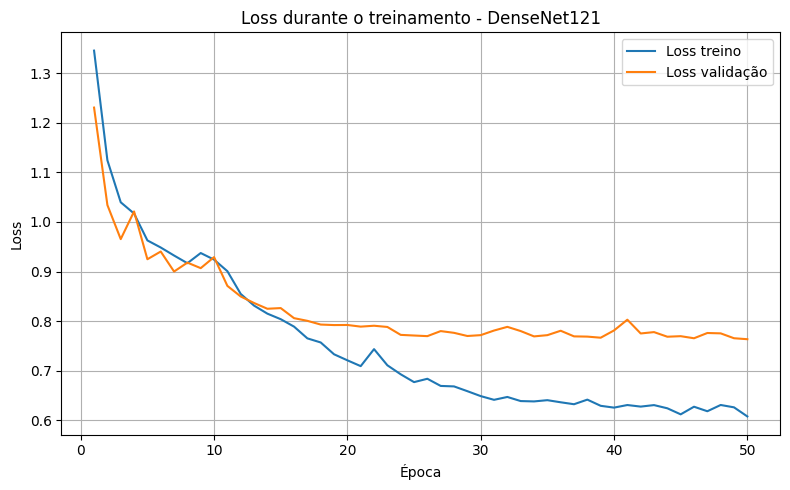

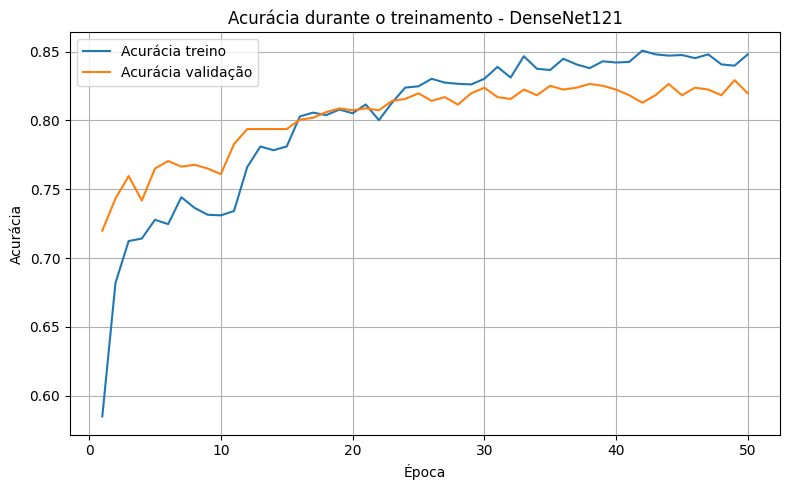

Figuras salvas em:
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_loss.png
/home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_accuracy.png


In [16]:
# CÉLULA 17 - Gerar gráficos de loss e acurácia

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_loss"], label="Loss treino")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Loss validação")
plt.title(f"Loss durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_loss.png"
plt.savefig(loss_fig_path, dpi=300)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_accuracy"], label="Acurácia treino")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Acurácia validação")
plt.title(f"Acurácia durante o treinamento - {MODEL_NAME}")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_accuracy.png"
plt.savefig(acc_fig_path, dpi=300)
plt.show()

print("Figuras salvas em:")
print(loss_fig_path)
print(acc_fig_path)

In [17]:
# CÉLULA EXTRA - Função de avaliação com TTA simples

def evaluate_with_tta(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs_original = model(images)

            images_flipped = torch.flip(images, dims=[3])
            outputs_flipped = model(images_flipped)

            outputs = (outputs_original + outputs_flipped) / 2.0

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(predicted.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [18]:
# CÉLULA 18 - Avaliação final no conjunto de teste

if USE_TTA_EVAL:
    test_loss, test_accuracy, y_true, y_pred = evaluate_with_tta(
        model,
        test_loader,
        criterion,
        device
    )
else:
    test_loss, test_accuracy, y_true, y_pred = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)

Loss no teste: 0.7117023187477299
Acurácia no teste: 0.8240109140518418


In [19]:
# CÉLULA 19 - Gerar relatório de classificação

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=4
)

print(report)

report_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_classification_report.txt"
report_path.write_text(report, encoding="utf-8")

print("Relatório salvo em:", report_path)

                           precision    recall  f1-score   support

          Sem retinopatia     0.9669    0.9695    0.9682       361
         Retinopatia leve     0.5946    0.5946    0.5946        74
     Retinopatia moderada     0.7573    0.7800    0.7685       200
       Retinopatia severa     0.5500    0.5641    0.5570        39
Retinopatia proliferativa     0.6275    0.5424    0.5818        59

                 accuracy                         0.8240       733
                macro avg     0.6992    0.6901    0.6940       733
             weighted avg     0.8226    0.8240    0.8230       733

Relatório salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_classification_report.txt


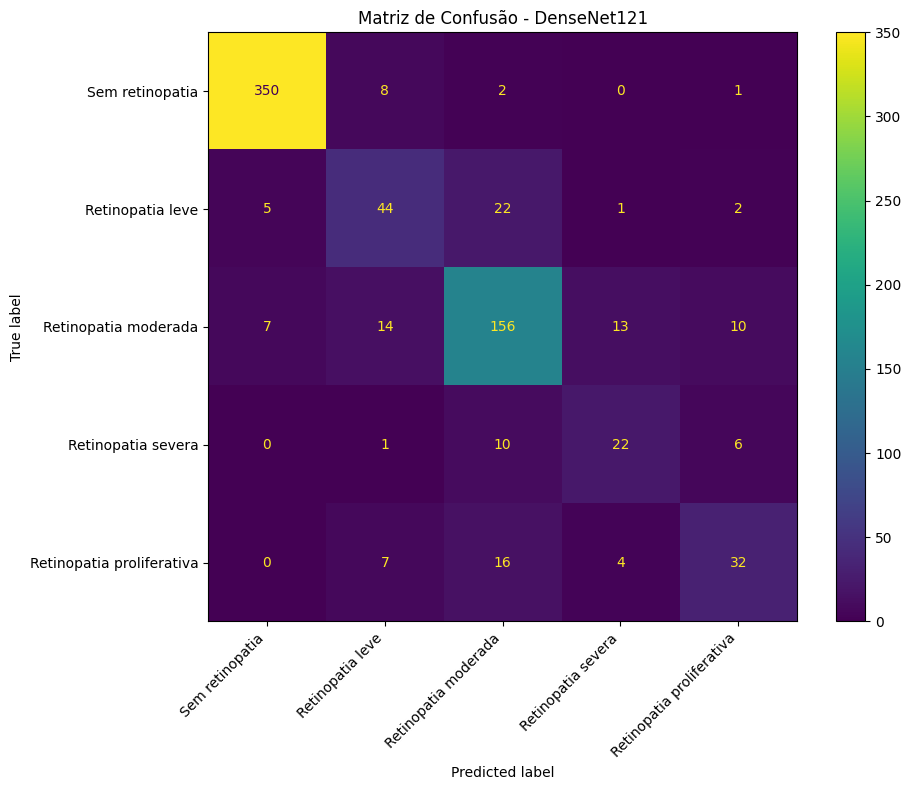

Matriz salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_confusion_matrix.csv
Figura salva em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/figures/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_confusion_matrix.png


In [20]:
# CÉLULA 20 - Gerar matriz de confusão

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_labels,
    columns=class_labels
)

cm_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.csv"
cm_df.to_csv(cm_path, encoding="utf-8-sig")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="viridis", values_format="d")
plt.title(f"Matriz de Confusão - {MODEL_NAME}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

cm_fig_path = FIGURES_DIR / f"{MODEL_OUTPUT_KEY}_confusion_matrix.png"
plt.savefig(cm_fig_path, dpi=300)
plt.show()

print("Matriz salva em:", cm_path)
print("Figura salva em:", cm_fig_path)

In [ ]:
# CÉLULA 21 - Salvar modelo final e resumo de métricas

final_model_path = MODEL_OUTPUT_DIR / f"{MODEL_OUTPUT_KEY}_final.pt"
torch.save(model.state_dict(), final_model_path)

summary_metrics = {
    "model": MODEL_NAME,
    "framework": "PyTorch",
    "experiment_name": EXPERIMENT_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "epochs_head_configured": EPOCHS_HEAD,
    "epochs_fine_tuning_configured": EPOCHS_FINE_TUNING,
    "epochs_completed_total": int(len(history_df)),
    "batch_size": BATCH_SIZE,
    "image_size": list(IMG_SIZE),
    "dropout_rate": DROPOUT_RATE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": PERSISTENT_WORKERS,
    "class_weight_mode": CLASS_WEIGHT_MODE,
    "class_weights": class_weights,
    "loss_function": LOSS_FUNCTION,
    "focal_gamma": FOCAL_GAMMA if LOSS_FUNCTION == "focal" else None,
    "label_smoothing": LABEL_SMOOTHING if LOSS_FUNCTION == "cross_entropy" else None,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "use_crop_black_borders": USE_CROP_BLACK_BORDERS,
    "crop_threshold": CROP_THRESHOLD,
    "split_strategy": "60% treino / 20% validação / 20% teste",
    "preprocess_input": "torchvision.transforms.Normalize(mean=ImageNet, std=ImageNet)",
    "data_augmentation": {
        "Resize": list(IMG_SIZE),
        "RandomRotation": 8,
        "RandomAffine_translate": [0.03, 0.03],
        "RandomAffine_scale": [0.95, 1.05],
        "RandomHorizontalFlip": 0.5,
    },
    "run_fine_tuning": True,
    "fine_tuning_scope": FINE_TUNING_SCOPE,
    "fine_tuning_layers": (
        "features.denseblock4 + features.norm5 + classifier"
        if FINE_TUNING_SCOPE == "denseblock4"
        else "features.denseblock3 + features.transition3 + features.denseblock4 + features.norm5 + classifier"
    ),
    "head_learning_rate": HEAD_LEARNING_RATE,
    "fine_tuning_learning_rate": FINE_TUNING_LEARNING_RATE,
    "head_training_time_seconds": float(head_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "gpu_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "final_model_path": str(final_model_path),
    "best_head_checkpoint_path": str(checkpoint_head_path),
    "best_fine_checkpoint_path": str(checkpoint_fine_path),
}

summary_path = METRICS_DIR / f"{MODEL_OUTPUT_KEY}_summary_metrics.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=4, ensure_ascii=False)

print("Modelo final salvo em:", final_model_path)
print("Resumo salvo em:", summary_path)
summary_metrics


Modelo final salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/models/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_final.pt
Resumo salvo em: /home/avell/Documentos/Caio/tcc-retinopatia-diabetica/results/metrics/densenet121_pytorch_gpu_v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5_summary_metrics.json


{'model': 'DenseNet121',
 'framework': 'PyTorch',
 'experiment_name': 'v22_pytorch_gpu_448_bs24_workers8_sqrt_ce_labelsmooth0015_tta_eval_ft_denseblock3_4_lr1e5',
 'test_loss': 0.7117023187477299,
 'test_accuracy': 0.8240109140518418,
 'epochs_head_configured': 10,
 'epochs_fine_tuning_configured': 40,
 'epochs_completed_total': 50,
 'batch_size': 24,
 'image_size': [448, 448],
 'dropout_rate': 0.3,
 'num_workers': 8,
 'pin_memory': True,
 'persistent_workers': True,
 'class_weight_mode': 'sqrt',
 'class_weights': {0: 0.6369653353298114,
  1: 1.4068686076813568,
  2: 0.8564787951515439,
  3: 1.9462607827531127,
  4: 1.5755906434433453},
 'loss_function': 'cross_entropy',
 'focal_gamma': None,
 'label_smoothing': 0.015,
 'use_weighted_sampler': False,
 'use_crop_black_borders': False,
 'crop_threshold': 10,
 'split_strategy': '60% treino / 20% validação / 20% teste',
 'preprocess_input': 'torchvision.transforms.Normalize(mean=ImageNet, std=ImageNet)',
 'data_augmentation': {'Resize': [4

: 

## Observações

Este notebook está numerado por comentários de célula. Para as próximas alterações, use principalmente:

- **CÉLULA 03**: hiperparâmetros principais (`IMG_SIZE`, `BATCH_SIZE`, `CLASS_WEIGHT_MODE`, `LOSS_FUNCTION`, `USE_WEIGHTED_SAMPLER`, `FINE_TUNING_SCOPE`);
- **CÉLULA 09**: `DataLoader` e `WeightedRandomSampler`;
- **CÉLULA 10**: pesos por classe e função de perda;
- **CÉLULA 14**: escopo do fine-tuning.

Para comparação final no TCC, aplique a mesma configuração nos três modelos quando decidir a configuração final.
